In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline,make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix



In [21]:
Churn_Model=pd.read_csv('Telco-Customer-Churn.csv')

In [22]:
Churn_Model.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [23]:
Churn_Model['TotalCharges']=pd.to_numeric(Churn_Model['TotalCharges'],errors='coerce')
Churn_Model['TotalCharges'].fillna(Churn_Model['TotalCharges'].median(), inplace=True)

/tmp/ipykernel_6478/3923053301.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  Churn_Model['TotalCharges'].fillna(Churn_Model['TotalCharges'].median(), inplace=True)


In [28]:
drop_cols = [
    'customerID',
    'gender',
    'PhoneService',
    'InternetService',
    'StreamingTV',
    'StreamingMovies',
    'DeviceProtection',
    'PaperlessBilling',
    'PaymentMethod',
    'MultipleLines',
    'TotalCharges',
    'SeniorCitizen'
]

In [31]:
Churn_Model = Churn_Model.drop(drop_cols, axis=1, errors='ignore')

In [32]:
Churn_Model.head()

,Partner,Dependents,tenure,OnlineSecurity,OnlineBackup,TechSupport,Contract,MonthlyCharges,Churn
0,Yes,No,1,No,Yes,No,Month-to-month,29.85,No
1,No,No,34,Yes,No,No,One year,56.95,No
2,No,No,2,Yes,Yes,No,Month-to-month,53.85,Yes
3,No,No,45,Yes,No,Yes,One year,42.30,No
4,No,No,2,No,No,No,Month-to-month,70.70,Yes


In [33]:
cat_cols=['Partner','Dependents','OnlineSecurity','OnlineBackup','TechSupport','Contract']
num_cols=['tenure','MonthlyCharges']

In [34]:
x_train,x_test,y_train,y_test=train_test_split(Churn_Model.drop('Churn',axis=1),Churn_Model['Churn'],test_size=0.2,random_state=42)

In [41]:
transformer=ColumnTransformer([
    ('cat',OneHotEncoder(drop='first',sparse_output=False,handle_unknown='ignore'),cat_cols),
    ('num',StandardScaler(),num_cols)
])

In [42]:
x_train_transformed=transformer.fit_transform(x_train)
x_test_transformed=transformer.transform(x_test)

In [44]:
pipeline=make_pipeline(cat_cols,num_cols)

In [47]:
rf=RandomForestClassifier()
rf.fit(x_train_transformed,y_train)




RandomForestClassifier()

BUINESS INSIGHTS



TOP CHURN DRIVERS
                                Feature  Importance
                    num__MonthlyCharges    0.442812
                            num__tenure    0.313645
                 cat__Contract_Two year    0.049117
                 cat__Contract_One year    0.033239
                cat__OnlineSecurity_Yes    0.032801
                   cat__TechSupport_Yes    0.025819
                  cat__OnlineBackup_Yes    0.021382
                    cat__Dependents_Yes    0.019918
                       cat__Partner_Yes    0.019502
  cat__OnlineBackup_No internet service    0.014870
cat__OnlineSecurity_No internet service    0.014237
   cat__TechSupport_No internet service    0.012659


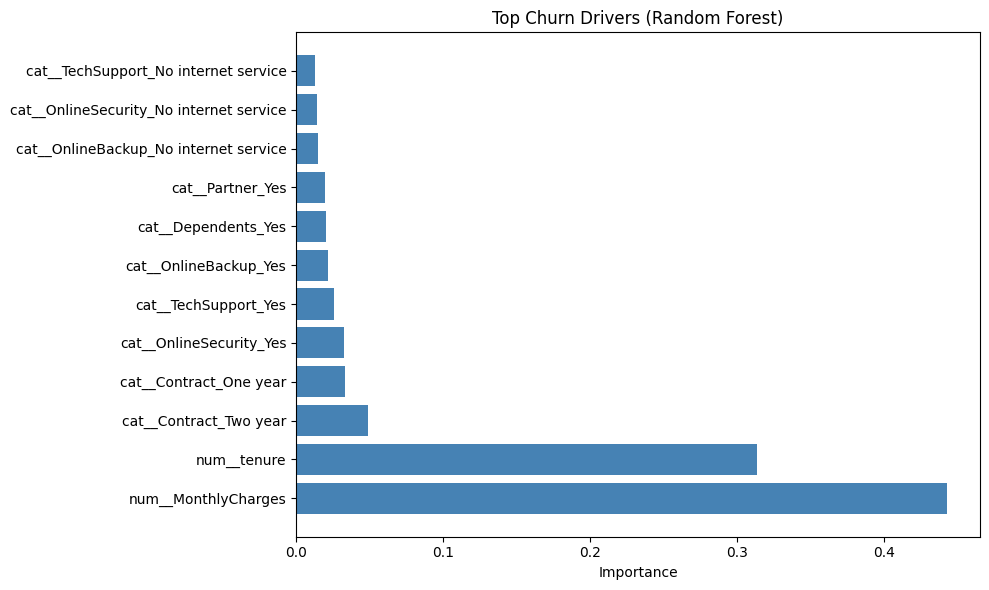

In [49]:

feature_names = transformer.get_feature_names_out()

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n" + "="*60)
print("TOP CHURN DRIVERS")
print("="*60)
print(importance_df.to_string(index=False))

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='steelblue')
plt.xlabel('Importance')
plt.title('Top Churn Drivers (Random Forest)')
plt.tight_layout()
plt.show()

In [56]:
import joblib
pipeline = Pipeline([
    ('transformer', transformer),
    ('classifier', rf)
])

pipeline.fit(x_train, y_train)

joblib.dump(pipeline, 'churn_pipeline.joblib')
print(" Model saved as 'churn_pipeline.joblib'")

 Model saved as 'churn_pipeline.joblib'


In [58]:
pipeline=joblib.load('churn_pipeline.joblib')

In [75]:

import joblib
import pandas as pd

pipeline = joblib.load('churn_pipeline.joblib')


new_customer = pd.DataFrame([{
    'Partner': 'No',
    'Dependents': 'No',
    'tenure': 2,
    'OnlineSecurity': 'No',
    'OnlineBackup': 'No',
    'TechSupport': 'No',
    'Contract': 'Month-to-month',
    'MonthlyCharges': 85
}])


proba = pipeline.predict_proba(new_customer)[0][1]
pred = pipeline.predict(new_customer)[0]

print("="*50)
print("PREDICTION RESULT")
print("="*50)
print(f"Churn Probability: {proba:.2%}")
print(f"Prediction: {'⚠️ CHURN' if pred == 1 else '✅ STAY'}")

if proba > 0.6:
    print("Action: Offer discount NOW!")
elif proba > 0.3:
    print("Action: Send engagement email")
else:
    print("Action: No action needed")

PREDICTION RESULT
Churn Probability: 95.00%
Prediction: ✅ STAY
Action: Offer discount NOW!
